In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
positive = pd.read_csv('../../data/train_tp.csv')
negative = pd.read_csv('../../data/train_fp.csv')

In [3]:
positive['species_id'] = positive['species_id'].astype(str).str.zfill(2)
negative['species_id'] = negative['species_id'].astype(str).str.zfill(2)

In [4]:
positive['songtype_id'] = positive['songtype_id'].astype(str)
negative['songtype_id'] = negative['songtype_id'].astype(str)

In [5]:
positive.shape, negative.shape

((1216, 7), (7781, 7))

In [6]:
positive.head(20)

,recording_id,species_id,songtype_id,t_min,f_min,t_max,f_max
0,003bec244,14,1,44.5440,2531.250,45.1307,5531.25
1,006ab765f,23,1,39.9615,7235.160,46.0452,11283.40
2,007f87ba2,12,1,39.1360,562.500,42.2720,3281.25
3,0099c367b,17,4,51.4206,1464.260,55.1996,4565.04
4,009b760e6,10,1,50.0854,947.461,52.5293,10852.70
5,00b404881,08,1,0.0747,3750.000,4.1973,5531.25
6,00d442df7,00,1,19.3653,5906.250,20.1600,8250.00
7,011f25080,18,1,5.6853,3187.500,6.3787,5062.50
8,015113cad,15,1,50.0533,93.750,53.3973,1125.00
9,0151b7d20,01,1,46.0320,3843.750,46.9280,5625.00


In [7]:
negative.head()

,recording_id,species_id,songtype_id,t_min,f_min,t_max,f_max
0,00204008d,21,1,13.8400,3281.2500,14.9333,4125.0000
1,00204008d,08,1,24.4960,3750.0000,28.6187,5531.2500
2,00204008d,04,1,15.0027,2343.7500,16.8587,4218.7500
3,003b04435,22,1,43.2533,10687.5000,44.8587,13687.5000
4,003b04435,23,1,9.1254,7235.1562,15.2091,11283.3984


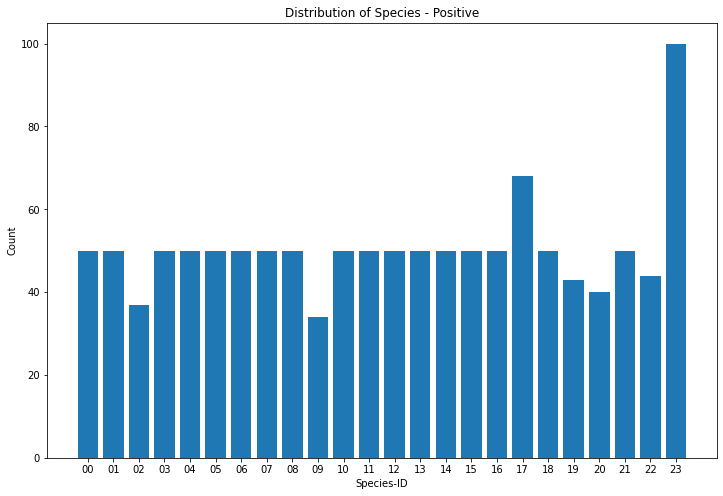

In [8]:
plt.figure(figsize=(12,8))
species = positive.groupby('species_id')['recording_id'].count().reset_index()
plt.bar(species.species_id, species.recording_id)
plt.ylabel('Count')
plt.xlabel('Species-ID')
plt.title('Distribution of Species - Positive')
plt.show()

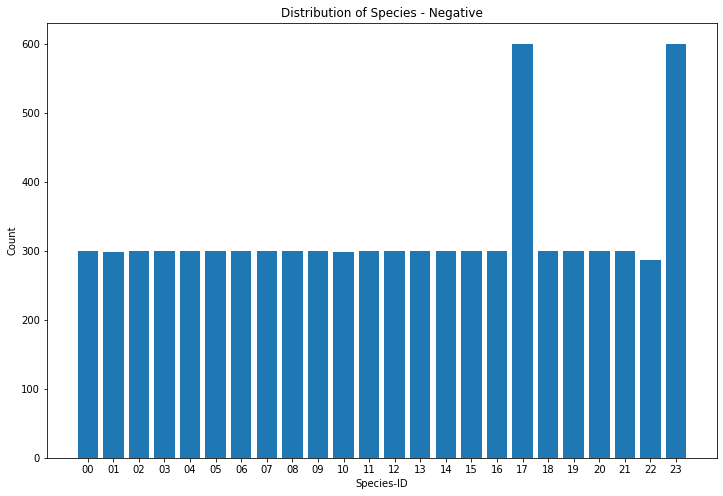

In [9]:
plt.figure(figsize=(12,8))
species = negative.groupby('species_id')['recording_id'].count().reset_index()
plt.bar(species.species_id, species.recording_id)
plt.ylabel('Count')
plt.xlabel('Species-ID')
plt.title('Distribution of Species - Negative')
plt.show()

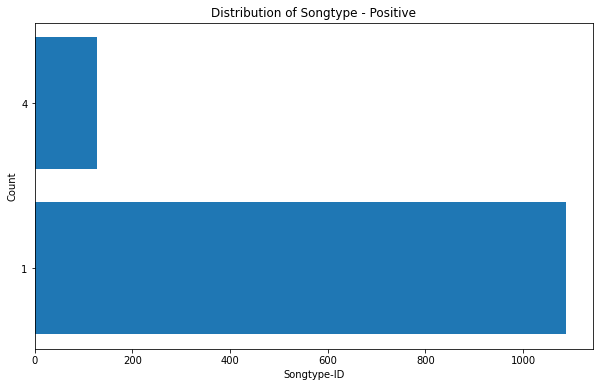

In [10]:
plt.figure(figsize=(10,6))
songtype = positive.groupby('songtype_id')['recording_id'].count().reset_index()
plt.barh(songtype.songtype_id, songtype.recording_id)
plt.ylabel('Count')
plt.xlabel('Songtype-ID')
plt.title('Distribution of Songtype - Positive')
plt.show()

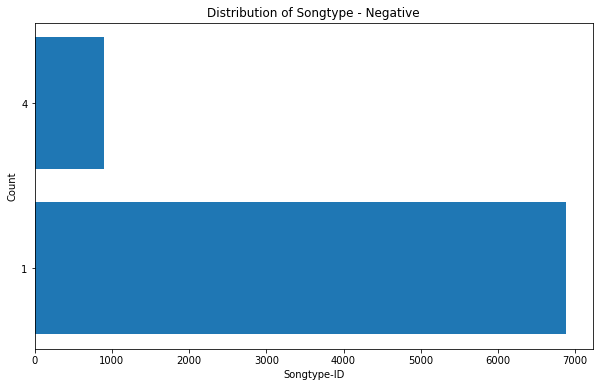

In [11]:
plt.figure(figsize=(10,6))
songtype = negative.groupby('songtype_id')['recording_id'].count().reset_index()
plt.barh(songtype.songtype_id, songtype.recording_id)
plt.ylabel('Count')
plt.xlabel('Songtype-ID')
plt.title('Distribution of Songtype - Negative')
plt.show()

In [12]:
data = positive.copy()
data['fold'] = -1
splits = StratifiedKFold(n_splits=5, random_state=2017, shuffle=True)
counter = 0
for train_idx, val_idx in splits.split(data.index, data.species_id):
    counter += 1
    data.loc[val_idx, 'fold'] = counter

In [13]:
data.fold.value_counts()

1    244
2    243
3    243
4    243
5    243
Name: fold, dtype: int64

In [14]:
data.pivot_table(index='species_id', columns='fold', values='recording_id', aggfunc='count')

fold,1,2,3,4,5
species_id,,,,,
00,10,10,10,10,10
01,10,10,10,10,10
02,7,8,8,7,7
03,10,10,10,10,10
04,10,10,10,10,10
05,10,10,10,10,10
06,10,10,10,10,10
07,10,10,10,10,10
08,10,10,10,10,10


In [15]:
data.head()

,recording_id,species_id,songtype_id,t_min,f_min,t_max,f_max,fold
0,003bec244,14,1,44.5440,2531.250,45.1307,5531.25,3
1,006ab765f,23,1,39.9615,7235.160,46.0452,11283.40,3
2,007f87ba2,12,1,39.1360,562.500,42.2720,3281.25,3
3,0099c367b,17,4,51.4206,1464.260,55.1996,4565.04,5
4,009b760e6,10,1,50.0854,947.461,52.5293,10852.70,3


In [16]:
data.to_csv('../../data/positive.csv', index=False)